In [4]:
pip install faker

In [5]:
from faker import Faker
import random
import pandas as pd

fake = Faker()

data = []

for i in range(10000):
    patient = {
        "Patient_ID": f"P{i+1:05d}",
        "Age": random.randint(20, 80),
        "Gender": random.choice(["Male", "Female"]),
        "Blood_Pressure": random.randint(80, 180),
        "Sugar_Level": random.randint(70, 200),
        "Cholesterol": random.randint(150, 300),
        "Heart_Rate": random.randint(60, 120)
    }
    data.append(patient)

df = pd.DataFrame(data)

df.to_csv("patient_data.csv", index=False)

print("Data generated successfully!")
print(df)

Data generated successfully!
     Patient_ID  Age  Gender  Blood_Pressure  Sugar_Level  Cholesterol  \
0        P00001   66  Female              86          174          160   
1        P00002   64  Female             109          192          297   
2        P00003   26    Male             176          160          185   
3        P00004   48  Female             135           99          228   
4        P00005   58    Male              83          145          238   
...         ...  ...     ...             ...          ...          ...   
9995     P09996   52    Male             151          126          275   
9996     P09997   78  Female             101          176          191   
9997     P09998   54  Female             160          195          157   
9998     P09999   46    Male              90           85          217   
9999     P10000   75    Male             123           96          287   

      Heart_Rate  
0             95  
1            109  
2            104  
3     

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  object
 1   Age             10000 non-null  int64 
 2   Gender          10000 non-null  object
 3   Blood_Pressure  10000 non-null  int64 
 4   Sugar_Level     10000 non-null  int64 
 5   Cholesterol     10000 non-null  int64 
 6   Heart_Rate      10000 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 547.0+ KB


In [7]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Blood_Pressure,0
Sugar_Level,0
Cholesterol,0
Heart_Rate,0


In [8]:
display(df.describe())

,Age,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,50.019800,130.367700,134.861100,224.787500,89.999300
std,17.660017,29.038137,37.641223,43.769763,17.561268
min,20.000000,80.000000,70.000000,150.000000,60.000000
25%,35.000000,105.000000,102.000000,187.000000,75.000000
50%,50.000000,130.500000,136.000000,225.000000,90.000000
75%,66.000000,155.000000,167.000000,263.000000,105.000000
max,80.000000,180.000000,200.000000,300.000000,120.000000


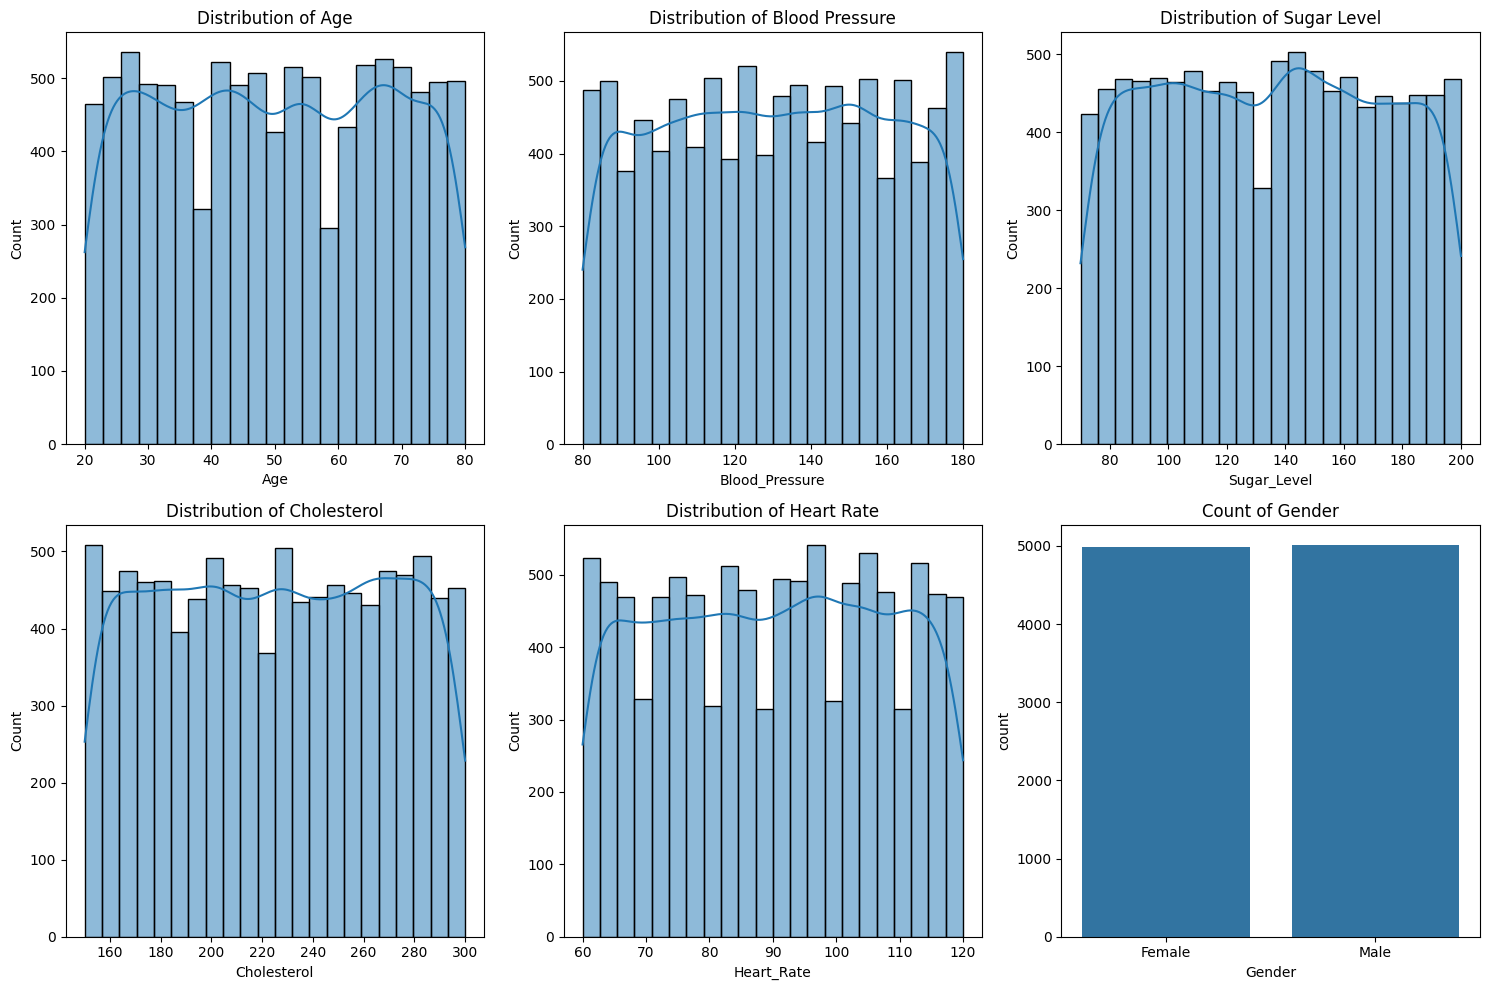

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(2, 3, 2)
sns.histplot(df['Blood_Pressure'], kde=True)
plt.title('Distribution of Blood Pressure')

plt.subplot(2, 3, 3)
sns.histplot(df['Sugar_Level'], kde=True)
plt.title('Distribution of Sugar Level')

plt.subplot(2, 3, 4)
sns.histplot(df['Cholesterol'], kde=True)
plt.title('Distribution of Cholesterol')

plt.subplot(2, 3, 5)
sns.histplot(df['Heart_Rate'], kde=True)
plt.title('Distribution of Heart Rate')

plt.subplot(2, 3, 6)
sns.countplot(x=df['Gender'])
plt.title('Count of Gender')

plt.tight_layout()
plt.show()

### Summary Statistics for Patient Health Metrics

### Patient Risk Classification

In [10]:
BLOOD_PRESSURE_HIGH = 140
BLOOD_PRESSURE_MEDIUM = 120
SUGAR_LEVEL_HIGH = 180
SUGAR_LEVEL_MEDIUM = 100
CHOLESTEROL_HIGH = 240
CHOLESTEROL_MEDIUM = 200

def classify_risk(patient):
    risk_score = 0

    if patient['Blood_Pressure'] >= BLOOD_PRESSURE_HIGH:
        risk_score += 2
    elif patient['Blood_Pressure'] >= BLOOD_PRESSURE_MEDIUM:
        risk_score += 1

    if patient['Sugar_Level'] >= SUGAR_LEVEL_HIGH:
        risk_score += 2
    elif patient['Sugar_Level'] >= SUGAR_LEVEL_MEDIUM:
        risk_score += 1

    if patient['Cholesterol'] >= CHOLESTEROL_HIGH:
        risk_score += 2
    elif patient['Cholesterol'] >= CHOLESTEROL_MEDIUM:
        risk_score += 1

    if risk_score >= 4:
        return 'High'
    elif risk_score >= 2:
        return 'Medium'
    else:
        return 'Low'

df['Risk_Category'] = df.apply(classify_risk, axis=1)

print("Patients classified into risk categories.")
display(df.head())

Patients classified into risk categories.


,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Category
0,P00001,66,Female,86,174,160,95,Low
1,P00002,64,Female,109,192,297,109,High
2,P00003,26,Male,176,160,185,104,Medium
3,P00004,48,Female,135,99,228,75,Medium
4,P00005,58,Male,83,145,238,115,Medium


/tmp/ipykernel_8227/3309556348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Category', data=df, palette='viridis', order=['Low', 'Medium', 'High'])


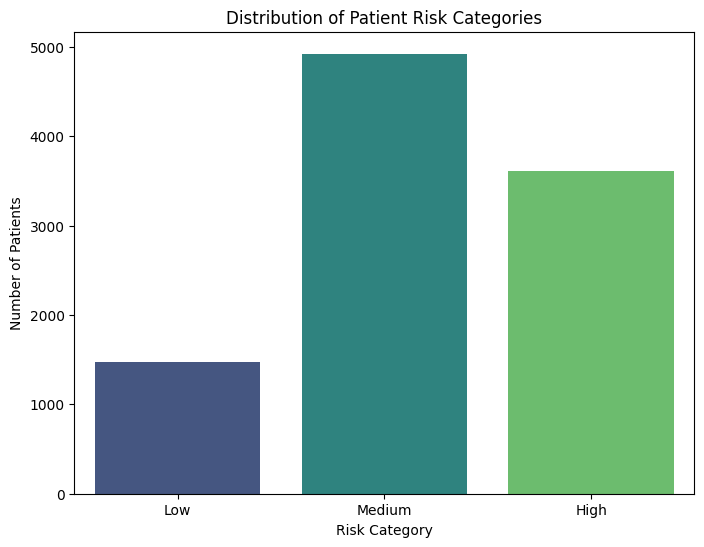

In [11]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Risk_Category', data=df, palette='viridis', order=['Low', 'Medium', 'High'])
plt.title('Distribution of Patient Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Number of Patients')
plt.show()

In [12]:
health_metrics = ['Blood_Pressure', 'Sugar_Level', 'Cholesterol', 'Heart_Rate']

for metric in health_metrics:
    print(f"\n--- {metric} ---")
    display(df[metric].describe())


--- Blood_Pressure ---


,Blood_Pressure
count,10000.000000
mean,130.367700
std,29.038137
min,80.000000
25%,105.000000
50%,130.500000
75%,155.000000
max,180.000000



--- Sugar_Level ---


,Sugar_Level
count,10000.000000
mean,134.861100
std,37.641223
min,70.000000
25%,102.000000
50%,136.000000
75%,167.000000
max,200.000000



--- Cholesterol ---


,Cholesterol
count,10000.000000
mean,224.787500
std,43.769763
min,150.000000
25%,187.000000
50%,225.000000
75%,263.000000
max,300.000000



--- Heart_Rate ---


,Heart_Rate
count,10000.000000
mean,89.999300
std,17.561268
min,60.000000
25%,75.000000
50%,90.000000
75%,105.000000
max,120.000000


### Identifying High-Risk Patients

In [13]:
high_risk_patients = df[df['Risk_Category'] == 'High']

print(f"Number of High-Risk Patients: {len(high_risk_patients)}")
display(high_risk_patients.head())

Number of High-Risk Patients: 3606


,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Category
1,P00002,64,Female,109,192,297,109,High
5,P00006,68,Male,152,130,270,74,High
7,P00008,74,Male,128,152,264,62,High
8,P00009,23,Male,146,136,246,112,High
11,P00012,38,Male,150,78,254,112,High


### Group-based Analysis

### Relationship Between Variables

/tmp/ipykernel_8227/2196244781.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Category', y='Sugar_Level', data=df, order=['Low', 'Medium', 'High'], palette='plasma')


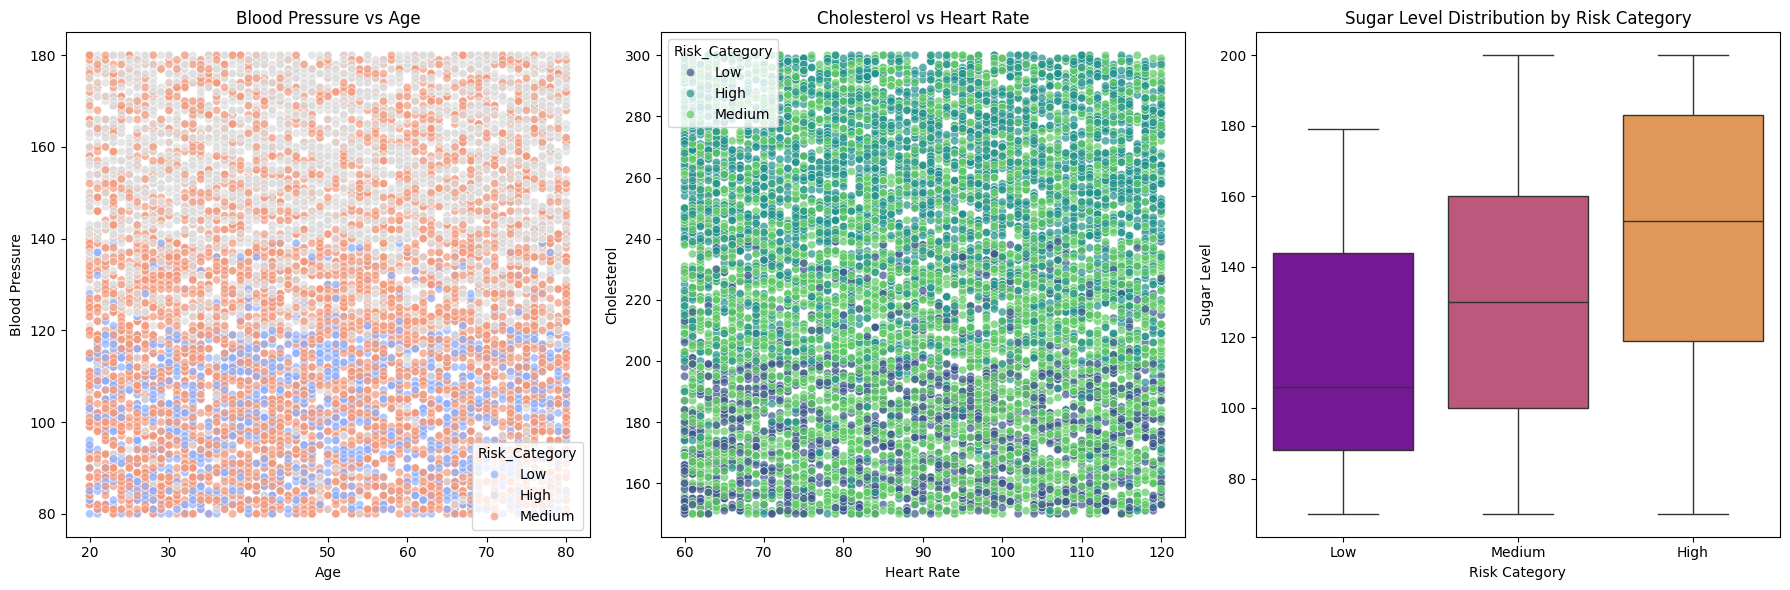

In [14]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='Age', y='Blood_Pressure', data=df, hue='Risk_Category', palette='coolwarm', alpha=0.7)
plt.title('Blood Pressure vs Age')
plt.xlabel('Age')
plt.ylabel('Blood Pressure')

# Cholesterol vs Heart Rate
plt.subplot(1, 3, 2)
sns.scatterplot(x='Heart_Rate', y='Cholesterol', data=df, hue='Risk_Category', palette='viridis', alpha=0.7)
plt.title('Cholesterol vs Heart Rate')
plt.xlabel('Heart Rate')
plt.ylabel('Cholesterol')

# Sugar Level vs Risk Category (using box plot for distribution)
plt.subplot(1, 3, 3)
sns.boxplot(x='Risk_Category', y='Sugar_Level', data=df, order=['Low', 'Medium', 'High'], palette='plasma')
plt.title('Sugar Level Distribution by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Sugar Level')

plt.tight_layout()
plt.show()

In [15]:
# Define age groups
age_bins = [0, 30, 45, 60, 75, 100]
age_labels = ['<30', '30-44', '45-59', '60-74', '75+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

print("Distribution of patients by Age Group:")
display(df['Age_Group'].value_counts().sort_index())

print("\nAverage health metrics by Age Group:")
display(df.groupby('Age_Group')[['Blood_Pressure', 'Sugar_Level', 'Cholesterol', 'Heart_Rate']].mean())

Distribution of patients by Age Group:


,count
Age_Group,
<30,1661
30-44,2469
45-59,2404
60-74,2475
75+,991



Average health metrics by Age Group:


/tmp/ipykernel_8227/3884102832.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('Age_Group')[['Blood_Pressure', 'Sugar_Level', 'Cholesterol', 'Heart_Rate']].mean())


,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
Age_Group,,,,
<30,128.554485,136.966285,225.788682,89.339554
30-44,130.310247,134.232483,224.162009,90.227217
45-59,131.066556,133.801165,225.351498,90.158486
60-74,130.929697,134.440000,223.674747,89.913535
75+,130.451060,136.521695,226.078708,90.365288


In [16]:
print("Average health metrics by Gender:")
display(df.groupby('Gender')[['Blood_Pressure', 'Sugar_Level', 'Cholesterol', 'Heart_Rate']].mean())

print("\nRisk category distribution by Gender:")
display(pd.crosstab(df['Gender'], df['Risk_Category'], normalize='index'))

Average health metrics by Gender:


,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
Gender,,,,
Female,130.569737,134.917921,224.694361,90.045956
Male,130.167032,134.804664,224.880008,89.952960



Risk category distribution by Gender:


Risk_Category,High,Low,Medium
Gender,,,
Female,0.362432,0.145896,0.491672
Male,0.358780,0.148096,0.493123


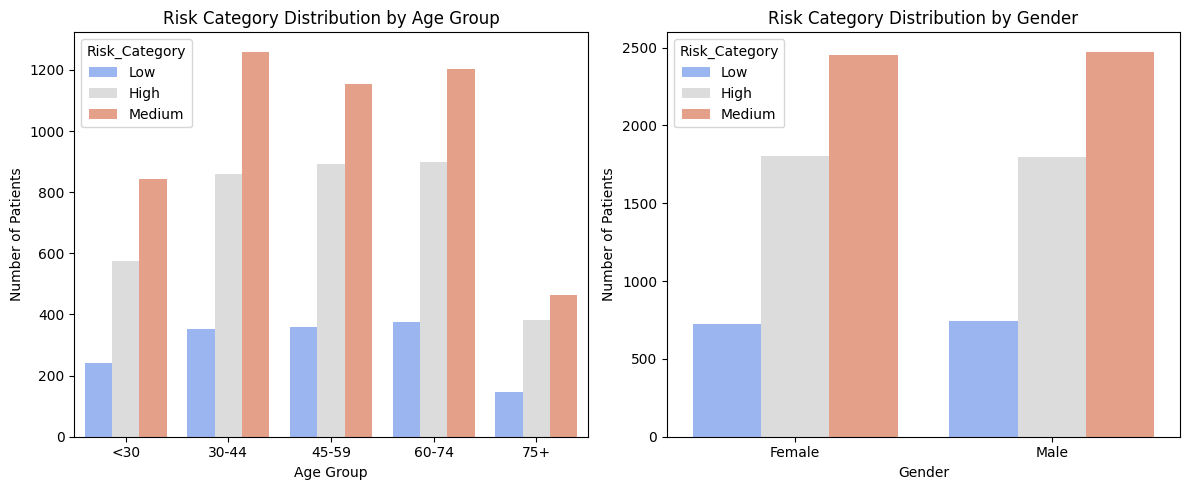

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Age_Group', hue='Risk_Category', data=df, palette='coolwarm', order=age_labels)
plt.title('Risk Category Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')

plt.subplot(1, 2, 2)
sns.countplot(x='Gender', hue='Risk_Category', data=df, palette='coolwarm')
plt.title('Risk Category Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

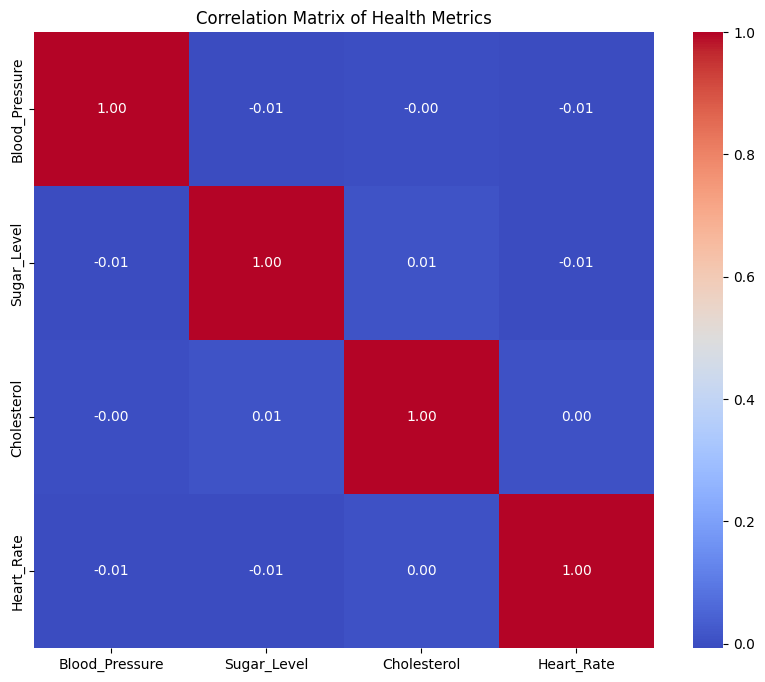

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[health_metrics].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Health Metrics')
plt.show()